Lo que se desea hacer aca es, que despues de realizar el modelo Random Forest en los raster del Sentinel-2 (Tres Arroyos),
Y haber generado un modelo de RandomForest en este. Y nos de un resultado.
Que como veremos, tendra una buena precisión, pero se va a ver muy granulado en algunas secciones.

Aplicaremos CEWS al resultado de ese modelo de RandomForest x pixel, y ver si suaviza y determina mejor las clases Campo Cultivo, Berbecho y No Agricola

In [3]:
import numpy as np
import pandas as pd
import rasterio
import time
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from joblib import load, dump

In [4]:
import os

# Configuracion de paths relativos desde el notebook
# El notebook esta en Joan/, subimos un nivel para llegar a la raiz del proyecto
# En Jupyter, usamos el directorio de trabajo actual y verificamos si estamos en Joan/
cwd = os.getcwd()

# Detectar si estamos en la carpeta Joan o en la raiz del proyecto
if os.path.basename(cwd) == 'Joan':
    # Si estamos en Joan/, subimos un nivel
    PROJECT_ROOT = os.path.dirname(cwd)
    JOAN_DIR = cwd
else:
    # Si estamos en la raiz, Joan/ esta dentro
    PROJECT_ROOT = cwd
    JOAN_DIR = os.path.join(cwd, "Joan")

PROJECT_ROOT = os.path.abspath(PROJECT_ROOT)
JOAN_DIR = os.path.abspath(JOAN_DIR)

# Directorio de datos procesados (dentro de Joan/)
DATA_PROC_DIR = os.path.join(JOAN_DIR, "proc_joan")

# Raster de predicciones: esta en data/proc/ (relativo a la raiz del proyecto)
PREDICCIONES_TIFF = os.path.join(PROJECT_ROOT, "data", "proc", "20_predicciones_rf_coronel_suarez.tif")

# Convertir a rutas absolutas para verificacion
PREDICCIONES_TIFF_ABS = os.path.abspath(PREDICCIONES_TIFF)
DATA_PROC_DIR_ABS = os.path.abspath(DATA_PROC_DIR)

print(f"Configuracion de rutas:")
print(f"  Directorio actual: {cwd}")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  JOAN_DIR: {JOAN_DIR}")
print(f"  DATA_PROC_DIR: {DATA_PROC_DIR}")
print(f"  PREDICCIONES_TIFF: {PREDICCIONES_TIFF}")

print(f"\nValidacion de archivo TIFF:")
if os.path.exists(PREDICCIONES_TIFF):
    print(f"  [OK] Archivo encontrado: {PREDICCIONES_TIFF}")
    with rasterio.open(PREDICCIONES_TIFF) as src:
        print(f"  Numero de bandas: {src.count}")
        print(f"  Dimensiones: {src.height} x {src.width}")
        print(f"  Data type: {src.dtypes[0]}")
        print(f"  CRS: {src.crs}")
        print(f"\n  Descripcion de bandas:")
        for i in range(1, src.count + 1):
            desc = src.descriptions[i-1] if src.descriptions[i-1] else f"Banda {i}"
            print(f"    Banda {i}: {desc}")
        
        if src.count >= 2:
            print(f"\n  [OK] El archivo tiene al menos 2 bandas (valores reales en banda 1, predicciones en banda 2)")
            banda1_sample = src.read(1, window=((0, 10), (0, 10)))
            banda2_sample = src.read(2, window=((0, 10), (0, 10)))
            print(f"    Sample banda 1 (valores reales): min={banda1_sample.min()}, max={banda1_sample.max()}, mean={banda1_sample.mean():.2f}")
            print(f"    Sample banda 2 (predicciones): min={banda2_sample.min()}, max={banda2_sample.max()}, mean={banda2_sample.mean():.2f}")
        else:
            print(f"\n  [ERROR] El archivo tiene solo {src.count} banda(s). Se requieren al menos 2.")
else:
    print(f"  [ERROR] Archivo NO encontrado: {PREDICCIONES_TIFF}")
    print(f"  Buscando archivos .tif en {os.path.join(PROJECT_ROOT, 'data', 'proc')}:")
    proc_dir = os.path.join(PROJECT_ROOT, "data", "proc")
    if os.path.exists(proc_dir):
        tif_files = [f for f in os.listdir(proc_dir) if 'coronel' in f.lower() or 'suarez' in f.lower()]
        if tif_files:
            print("  Archivos .tif relacionados encontrados:")
            for archivo in tif_files[:10]:
                print(f"    - {archivo}")
            if len(tif_files) > 10:
                print(f"    ... y {len(tif_files) - 10} mas")
        else:
            print("  (ninguno relacionado con coronel suarez)")
    else:
        print(f"  Directorio {proc_dir} no existe")

Configuracion de rutas:
  Directorio actual: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\Joan
  PROJECT_ROOT: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola
  JOAN_DIR: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\Joan
  DATA_PROC_DIR: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\Joan\proc_joan
  PREDICCIONES_TIFF: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\data\proc\20_predicciones_rf_coronel_suarez.tif

Validacion de archivo TIFF:
  [OK] Archivo encontrado: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\data\proc\20_predicciones_rf_coronel_suarez.tif
  Numero de bandas: 2
  Dimensiones: 2651 x 2646
  Data type: uint8
  CRS: EPSG:32721

  Descripcion de bandas:
    Banda 1: Valores Reales (Categorías INTA agrupadas) - Clases: 0=CULTIVO AGRÍCOLA, 1=BARBECHO, 2=NO AGRÍCOLA, 2

## Carga de Datos de Predicciones (Coronel Diaz)

CARGANDO MAPAS DE PREDICCION (Coronel Suárez): bandas 1=INTA realidad, 2=predicciones
Abriendo c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\data\proc\20_predicciones_rf_coronel_suarez.tif -> bandas=2, dims=2651x2646
Dimensiones cargadas: 2651 x 2646


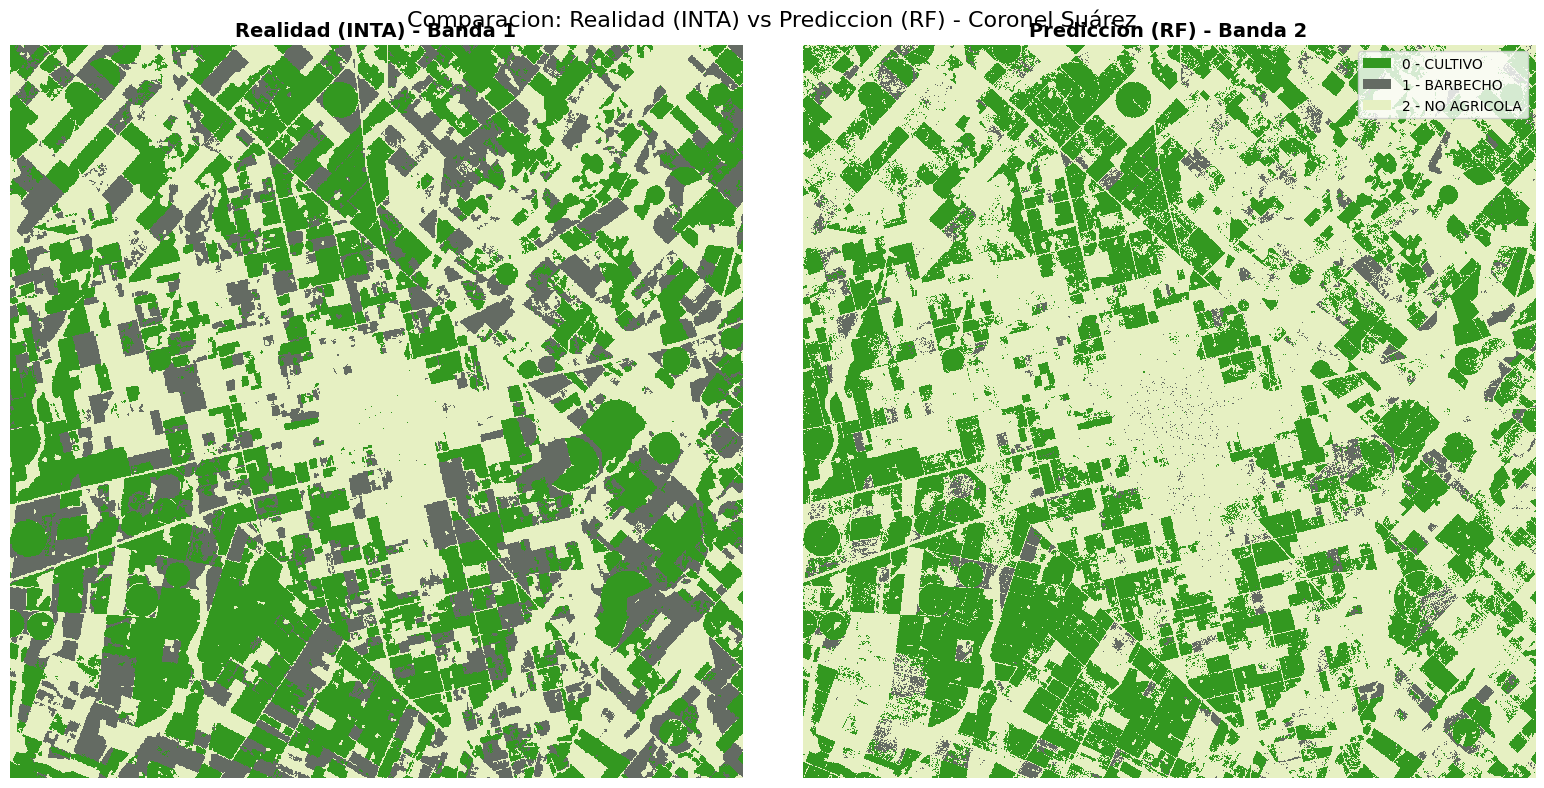


Accuracy espacial (sobre pixeles válidos): 0.7348 (73.48%)
Pixeles correctos: 5,153,912 de 7,014,119

[OK] Bandas guardadas en: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\Joan\proc_joan\20_predicciones_rf_coronel_suarez_b1_real.tif y c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\Joan\proc_joan\20_predicciones_rf_coronel_suarez_b2_pred.tif

[READY] mapa_realidad y mapa_prediccion preparados para CEWS


In [5]:
print("="*80)
print("CARGANDO MAPAS DE PREDICCION (Coronel Suárez): bandas 1=INTA realidad, 2=predicciones")
print("="*80)

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Abrimos el TIFF de predicciones (ya validado en la celda anterior)
if not os.path.exists(PREDICCIONES_TIFF):
    raise FileNotFoundError(f"No se encontro el TIFF de predicciones: {PREDICCIONES_TIFF}")

with rasterio.open(PREDICCIONES_TIFF) as src:
    meta_tif = src.meta.copy()
    print(f"Abriendo {PREDICCIONES_TIFF} -> bandas={src.count}, dims={src.height}x{src.width}")
    if src.count < 2:
        raise ValueError("El TIFF debe contener al menos 2 bandas: 1=real, 2=prediccion")
    mapa_realidad = src.read(1).astype(np.int32)
    mapa_prediccion = src.read(2).astype(np.int32)
    transform = src.transform
    crs = src.crs
    height, width = mapa_realidad.shape

# Normalizamos nodata a -1 si es necesario
if 'nodata' in meta_tif and meta_tif['nodata'] is not None:
    nod = meta_tif['nodata']
    mapa_realidad[mapa_realidad == nod] = -1
    mapa_prediccion[mapa_prediccion == nod] = -1

print(f"Dimensiones cargadas: {height} x {width}")

# Visualizacion comparativa: realidad vs prediccion
colores_clases = {0: '#339820', 1: '#646b63', 2: '#e6f0c2'}
cmap_custom = ListedColormap([colores_clases[0], colores_clases[1], colores_clases[2]])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax1, ax2 = axes
im1 = ax1.imshow(mapa_realidad, cmap=cmap_custom, vmin=0, vmax=2, interpolation='nearest')
ax1.set_title('Realidad (INTA) - Banda 1', fontsize=14, fontweight='bold')
ax1.axis('off')

im2 = ax2.imshow(mapa_prediccion, cmap=cmap_custom, vmin=0, vmax=2, interpolation='nearest')
ax2.set_title('Prediccion (RF) - Banda 2', fontsize=14, fontweight='bold')
ax2.axis('off')

handles = [Patch(facecolor=colores_clases[i], label=f'{i} - {"CULTIVO" if i==0 else ("BARBECHO" if i==1 else "NO AGRICOLA")}') for i in range(3)]
ax2.legend(handles=handles, loc='upper right')
plt.suptitle('Comparacion: Realidad (INTA) vs Prediccion (RF) - Coronel Suárez', fontsize=16)
plt.tight_layout()
plt.show()

# Estadisticas basicas de comparacion
mask_comparacion = (mapa_realidad >= 0) & (mapa_prediccion >= 0)
if mask_comparacion.sum() == 0:
    print('\n[WARN] No hay pixeles válidos para comparar (mask_comparacion es vacía).')
else:
    aciertos = (mapa_realidad[mask_comparacion] == mapa_prediccion[mask_comparacion]).sum()
    total_comparacion = mask_comparacion.sum()
    accuracy_espacial = aciertos / total_comparacion
    print(f"\nAccuracy espacial (sobre pixeles válidos): {accuracy_espacial:.4f} ({accuracy_espacial*100:.2f}%)")
    print(f"Pixeles correctos: {aciertos:,} de {total_comparacion:,}")

# Guardar copias por si se desean (banda 1 y 2) en proc_joan
os.makedirs(DATA_PROC_DIR, exist_ok=True)
output_b1 = os.path.join(DATA_PROC_DIR, '20_predicciones_rf_coronel_suarez_b1_real.tif')
output_b2 = os.path.join(DATA_PROC_DIR, '20_predicciones_rf_coronel_suarez_b2_pred.tif')

meta_save = meta_tif.copy()
meta_save.update({'count': 1, 'dtype': 'int32', 'nodata': -1})
with rasterio.open(output_b1, 'w', **meta_save) as dst:
    dst.write(mapa_realidad.astype(np.int32), 1)
    dst.set_band_description(1, 'INTA_real_banda1')
with rasterio.open(output_b2, 'w', **meta_save) as dst:
    dst.write(mapa_prediccion.astype(np.int32), 1)
    dst.set_band_description(1, 'RF_prediccion_banda2')

print(f"\n[OK] Bandas guardadas en: {output_b1} y {output_b2}")

# Dejamos las variables lista para la celda CEWS que viene después
print('\n[READY] mapa_realidad y mapa_prediccion preparados para CEWS')


## Aplicacion de Algoritmos de Suavizacion: Canny y Watershed

En esta seccion aplicaremos el algoritmo de deteccion de bordes Canny y el algoritmo de Watershed al mapa de prediccion del Random Forest para suavizar la granularidad y mejorar la segmentacion de los segmentos.

APLICANDO CEWS: CANNY EDGE DETECTION + WATERSHED (sobre banda 2: prediccion)

1. Normalizando mapa de prediccion para Canny...
2. Aplicando Canny Edge Detection...
3. Aplicando operaciones morfologicas (cierre y apertura)...
4. Aplicando Watershed...
   Segmentos identificados: 2494
5. Remapeando segmentos a clases originales...
[OK] CEWS aplicado exitosamente


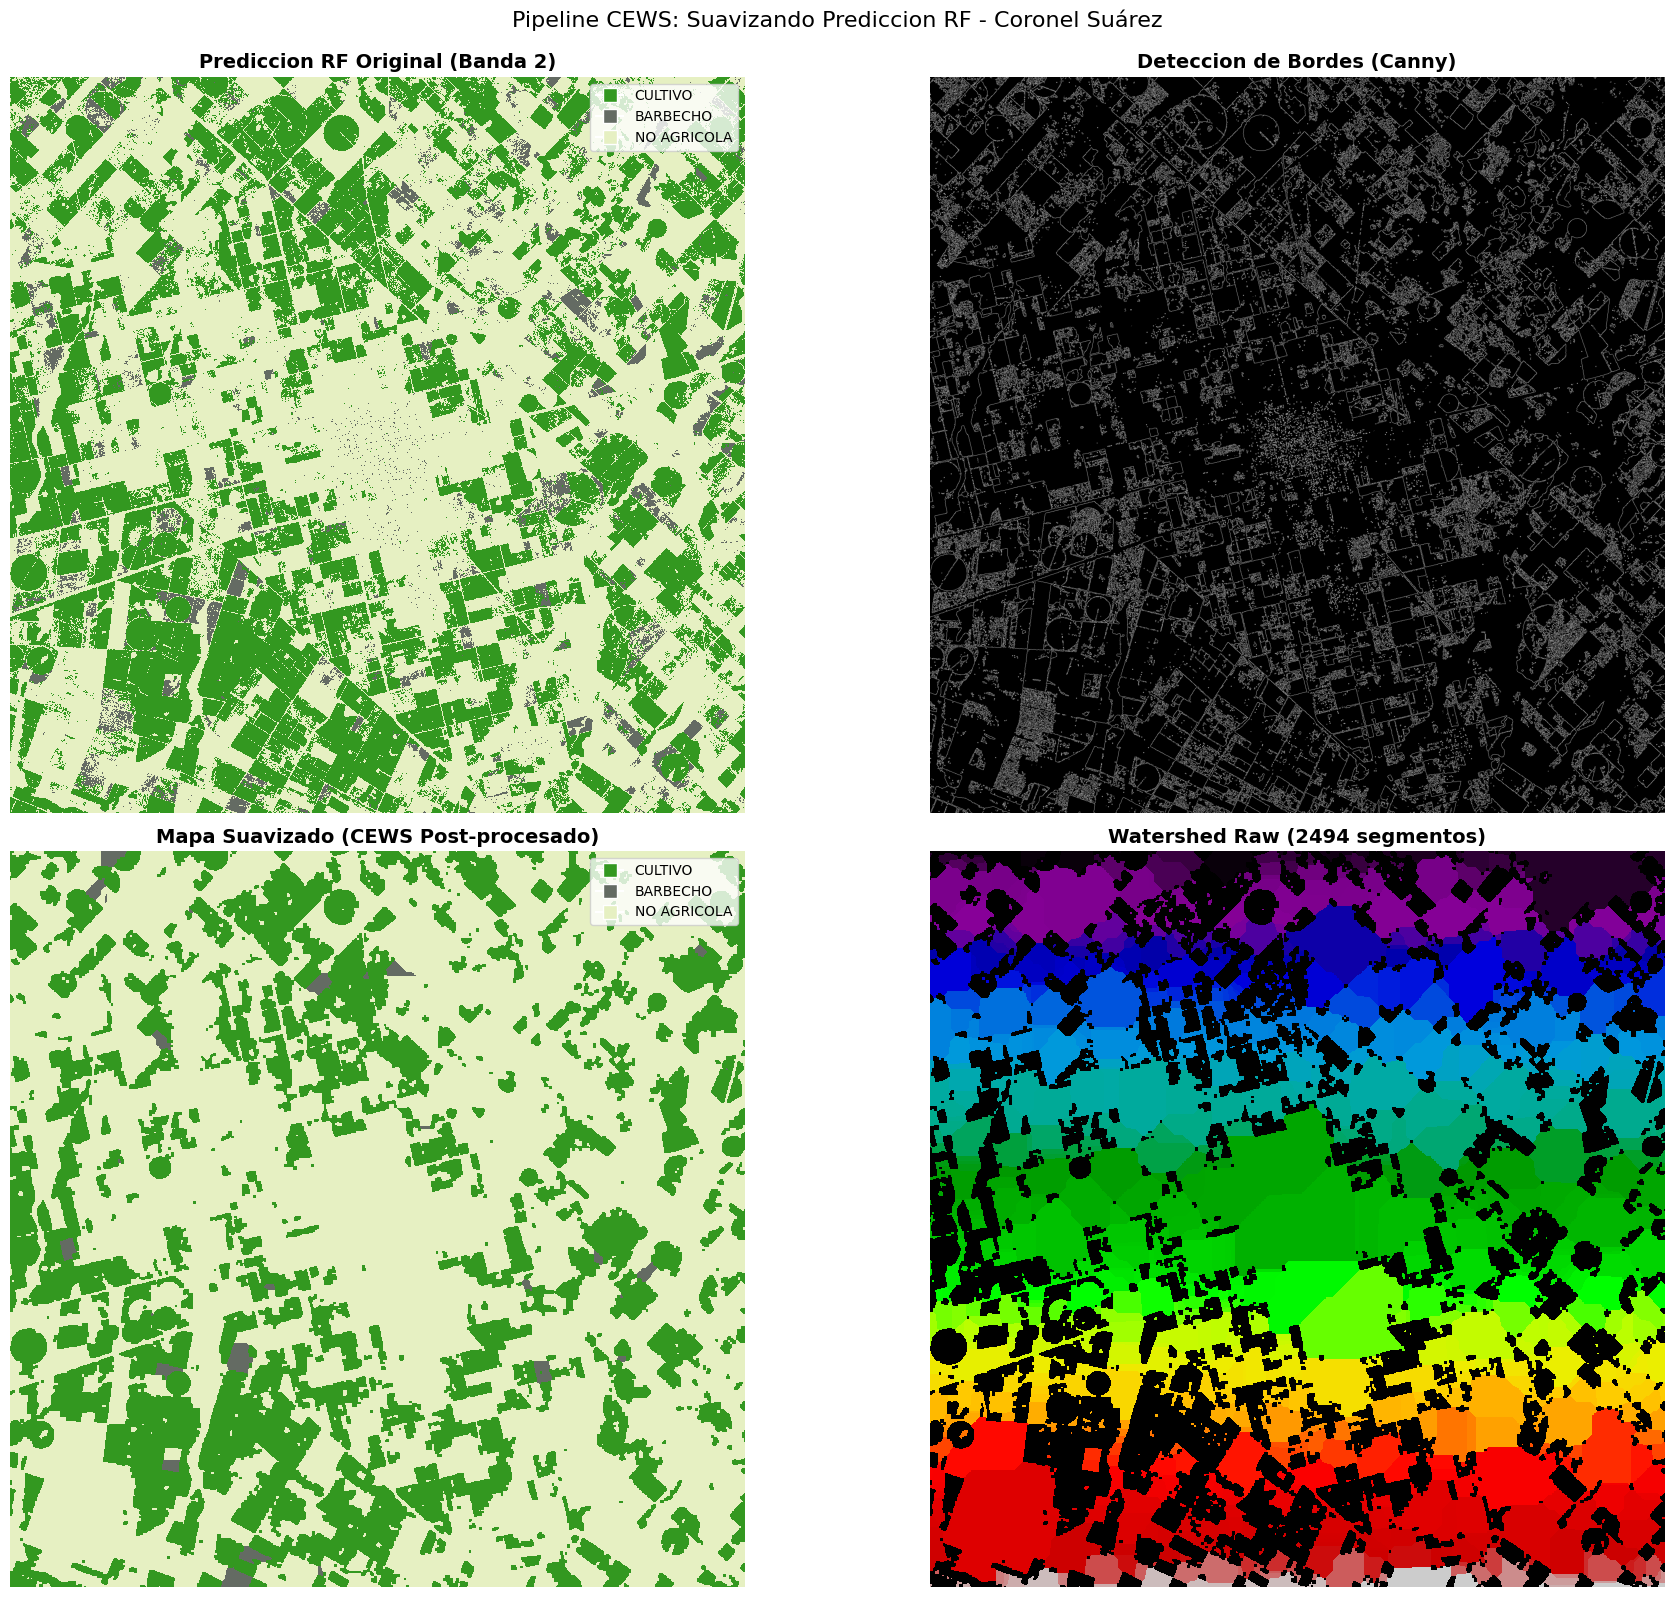


[OK] Visualizacion generada

Estadisticas del procesamiento:
  - Pixeles validos en prediccion: 7,014,119
  - Pixeles con bordes detectados (Canny): 583,596
  - Segmentos identificados (Watershed): 2494
  - Pixeles modificados por suavizado: 826,318 (16.92%)

Guardando mapa suavizado CEWS en: c:\Users\Leandro Escudero\OneDrive - Calice AI\Documentos\TP\ade_modelo_agricola\Joan\proc_joan\20_predicciones_rf_coronel_suarez_cews.tif
[OK] Mapa CEWS guardado en proc_joan


In [7]:
import cv2
from skimage import segmentation
from scipy import ndimage
from matplotlib.colors import ListedColormap

print("="*80)
print("APLICANDO CEWS: CANNY EDGE DETECTION + WATERSHED (sobre banda 2: prediccion)")
print("="*80)

print("\n1. Normalizando mapa de prediccion para Canny...")
mapa_norm = np.zeros_like(mapa_prediccion, dtype=np.uint8)
mapa_valido = mapa_prediccion >= 0
# escala simple para separar clases (0,1,2) en valores distinguibles para Canny
mapa_norm[mapa_valido] = mapa_prediccion[mapa_valido] * 100

print("2. Aplicando Canny Edge Detection...")
edges = cv2.Canny(mapa_norm, threshold1=50, threshold2=150)

print("3. Aplicando operaciones morfologicas (cierre y apertura)...")
kernel_morph = np.ones((5, 5), np.uint8)
mapa_suavizado = cv2.morphologyEx(mapa_norm, cv2.MORPH_CLOSE, kernel_morph, iterations=2)
mapa_suavizado = cv2.morphologyEx(mapa_suavizado, cv2.MORPH_OPEN, kernel_morph, iterations=1)

print("4. Aplicando Watershed...")
mapa_distancia = ndimage.distance_transform_edt(mapa_suavizado > 50)
local_maxima = ndimage.maximum_filter(mapa_distancia, size=15) == mapa_distancia
marcadores, num_marcadores = ndimage.label(local_maxima)
mapa_watershed_raw = segmentation.watershed(-mapa_distancia, marcadores, mask=(mapa_suavizado > 50))

print(f"   Segmentos identificados: {num_marcadores}")

print("5. Remapeando segmentos a clases originales...")
mapa_suavizado_clases = np.full_like(mapa_prediccion, -1, dtype=np.int32)

for seg_id in np.unique(mapa_watershed_raw):
    if seg_id == 0:
        continue
    mascara_segmento = mapa_watershed_raw == seg_id
    clases_en_segmento = mapa_prediccion[mascara_segmento]
    clases_validas = clases_en_segmento[clases_en_segmento >= 0]
    
    if len(clases_validas) > 0:
        clase_mayoritaria = np.bincount(clases_validas.astype(int)).argmax()
        mapa_suavizado_clases[mascara_segmento] = clase_mayoritaria

print("[OK] CEWS aplicado exitosamente")

colores_clases = {0: '#339820', 1: '#646b63', 2: '#e6f0c2'}
cmap_custom = ListedColormap([colores_clases[0], colores_clases[1], colores_clases[2]])

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

ax1 = axes[0, 0]
im1 = ax1.imshow(mapa_prediccion, cmap=cmap_custom, vmin=0, vmax=2, interpolation='nearest')
ax1.set_title('Prediccion RF Original (Banda 2)', fontsize=14, fontweight='bold')
ax1.axis('off')
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colores_clases[i], 
                       markersize=10, label=f'{["CULTIVO", "BARBECHO", "NO AGRICOLA"][i]}') 
           for i in range(3)]
ax1.legend(handles=handles, loc='upper right', fontsize=10)

ax2 = axes[0, 1]
im2 = ax2.imshow(edges, cmap='gray')
ax2.set_title('Deteccion de Bordes (Canny)', fontsize=14, fontweight='bold')
ax2.axis('off')

ax3 = axes[1, 0]
im3 = ax3.imshow(mapa_suavizado_clases, cmap=cmap_custom, vmin=0, vmax=2, interpolation='nearest')
ax3.set_title('Mapa Suavizado (CEWS Post-procesado)', fontsize=14, fontweight='bold')
ax3.axis('off')
ax3.legend(handles=handles, loc='upper right', fontsize=10)

ax4 = axes[1, 1]
im4 = ax4.imshow(mapa_watershed_raw, cmap='nipy_spectral', interpolation='nearest')
ax4.set_title(f'Watershed Raw ({num_marcadores} segmentos)', fontsize=14, fontweight='bold')
ax4.axis('off')

plt.suptitle('Pipeline CEWS: Suavizando Prediccion RF - Coronel Suárez', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n[OK] Visualizacion generada")
print(f"\nEstadisticas del procesamiento:")
print(f"  - Pixeles validos en prediccion: {np.sum(mapa_valido):,}")
print(f"  - Pixeles con bordes detectados (Canny): {np.sum(edges > 0):,}")
print(f"  - Segmentos identificados (Watershed): {num_marcadores}")

mask_cambio = (mapa_prediccion >= 0) & (mapa_suavizado_clases >= 0)
pixeles_cambiados = np.sum(mapa_prediccion[mask_cambio] != mapa_suavizado_clases[mask_cambio])
print(f"  - Pixeles modificados por suavizado: {pixeles_cambiados:,} ({100*pixeles_cambiados/np.sum(mask_cambio):.2f}%)")

# Guardar el mapa suavizado como GeoTIFF en proc_joan usando metadata del TIFF original
os.makedirs(DATA_PROC_DIR, exist_ok=True)
output_cews_path = os.path.join(DATA_PROC_DIR, "20_predicciones_rf_coronel_suarez_cews.tif")
print(f"\nGuardando mapa suavizado CEWS en: {output_cews_path}")

# obtenemos meta desde el archivo original para preservar georeferenciacion
with rasterio.open(PREDICCIONES_TIFF) as src:
    meta_out = src.meta.copy()
    meta_out.update({'count': 1, 'dtype': 'int32', 'nodata': -1})
    with rasterio.open(output_cews_path, 'w', **meta_out) as dst:
        dst.write(mapa_suavizado_clases.astype(np.int32), 1)
        dst.set_band_description(1, 'RF_prediccion_CEWS')

print("[OK] Mapa CEWS guardado en proc_joan")
